SECTION 0: DATA LOADING & CLEANING

Shape: (700, 20)

Column dtypes:
job_id                           int64
job_role                        object
industry                        object
country                         object
year                             int64
automation_risk_percent        float64
ai_replacement_score           float64
skill_gap_index                float64
salary_before_usd              float64
salary_after_usd               float64
salary_change_percent          float64
skill_demand_growth_percent    float64
remote_feasibility_score       float64
ai_adoption_level               object
education_requirement_level     object
automation_risk_category        object
skill_transition_pressure      float64
wage_volatility_index          float64
reskilling_urgency_score       float64
ai_disruption_intensity        float64
dtype: object

Missing values:
job_id                          0
job_role                        0
industry                        0
country           

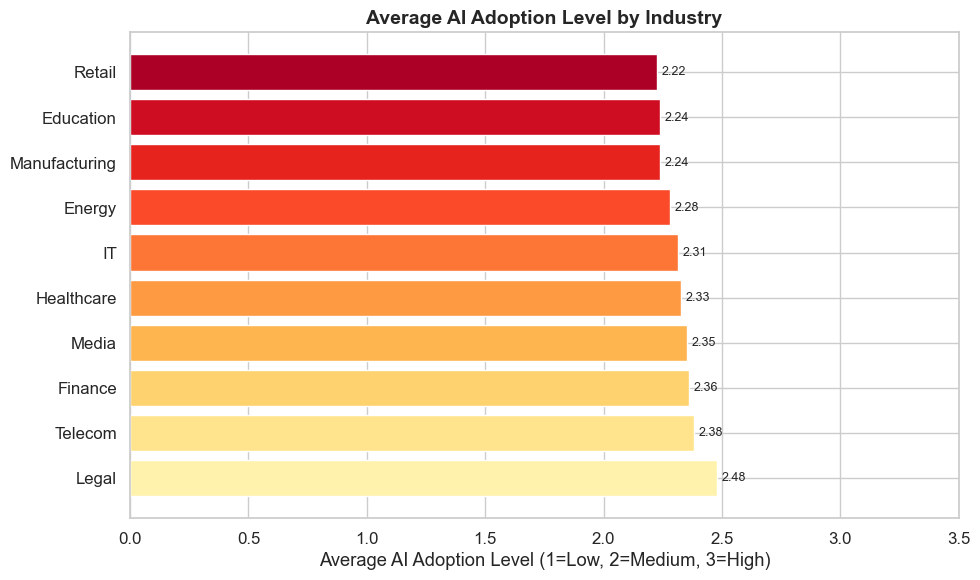

✓ Saved 1b_automation_risk_by_role.png


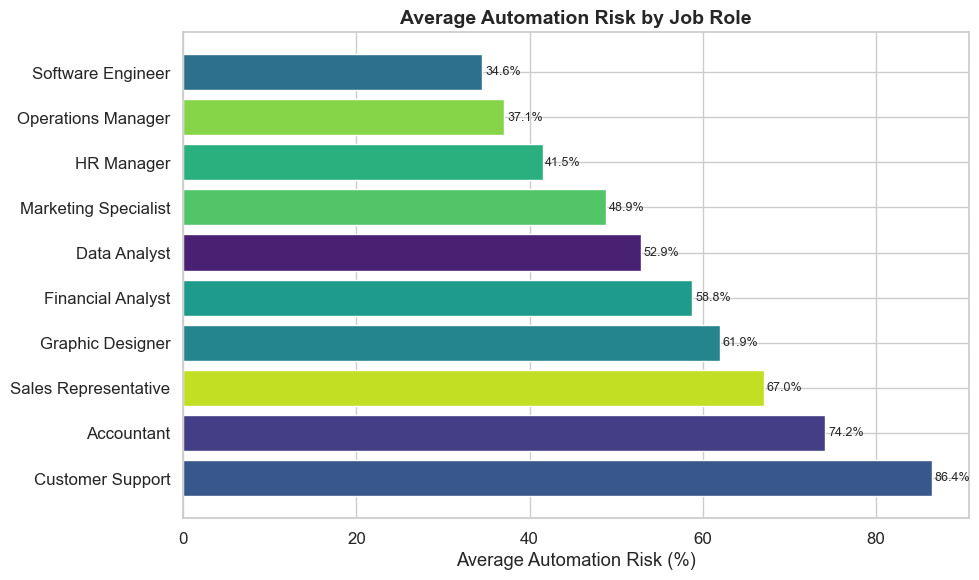

✓ Saved 1c_disruption_heatmap_role_industry.png


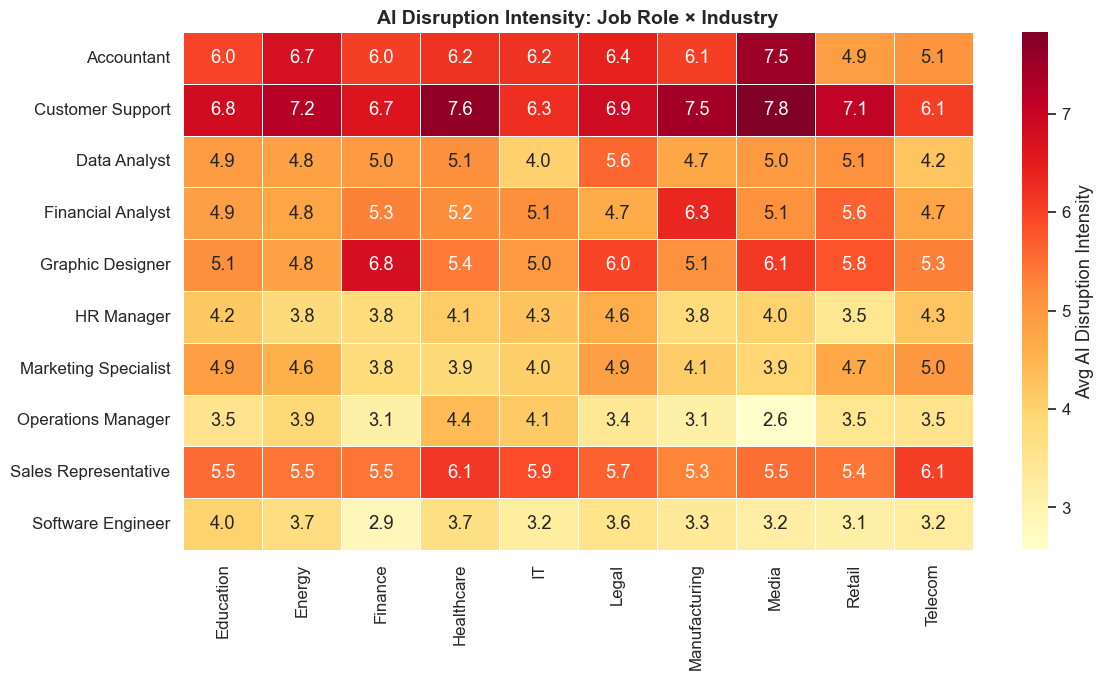

✓ Saved 1b_automation_risk_by_role.png


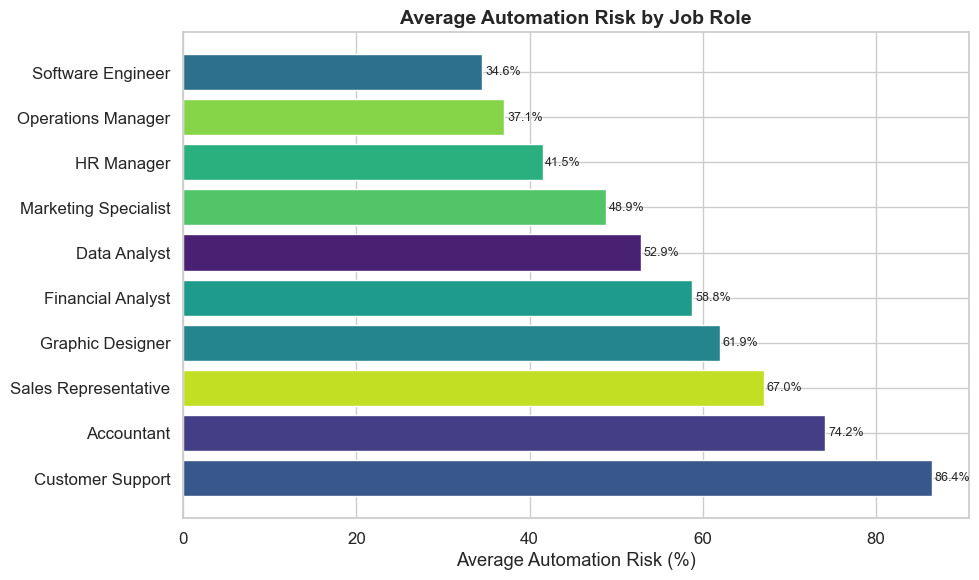


SECTION 2: FUTURE SKILL DEMAND
✓ Saved 2a_quadrant_scatter_KEY.png


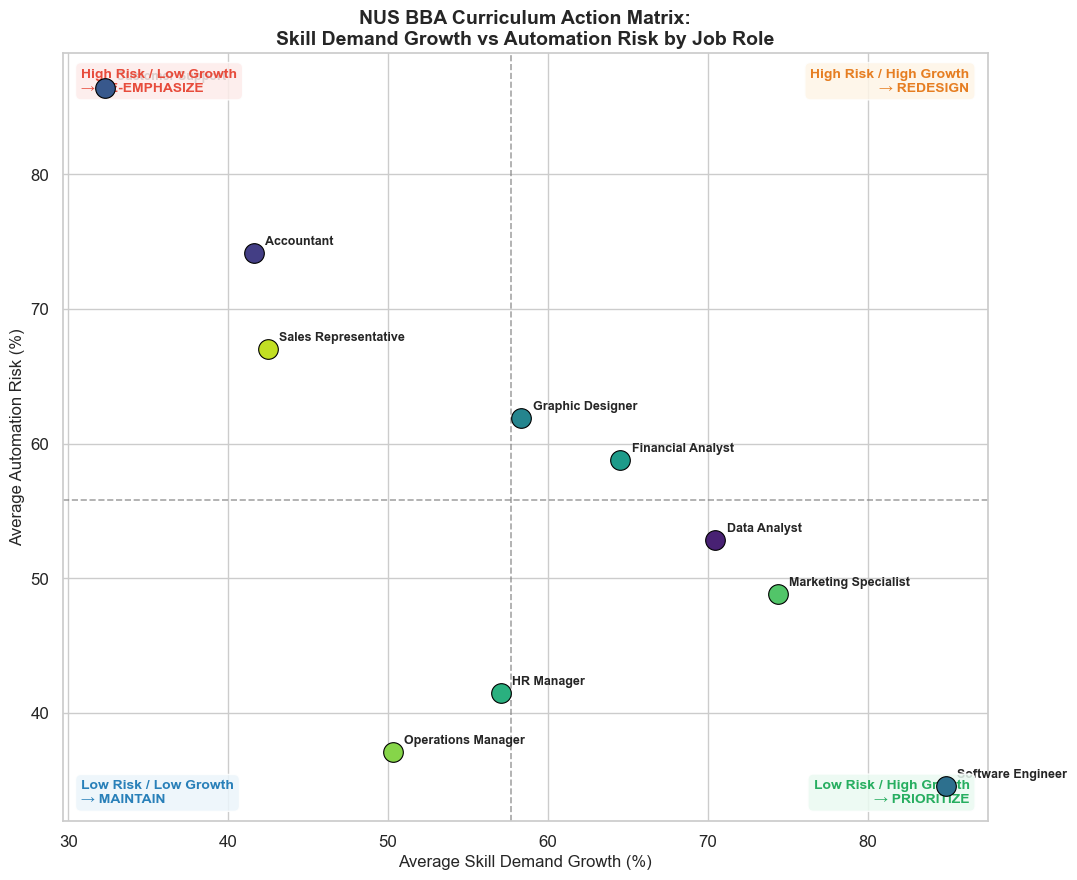

✓ Saved 2b_reskilling_urgency_by_role.png


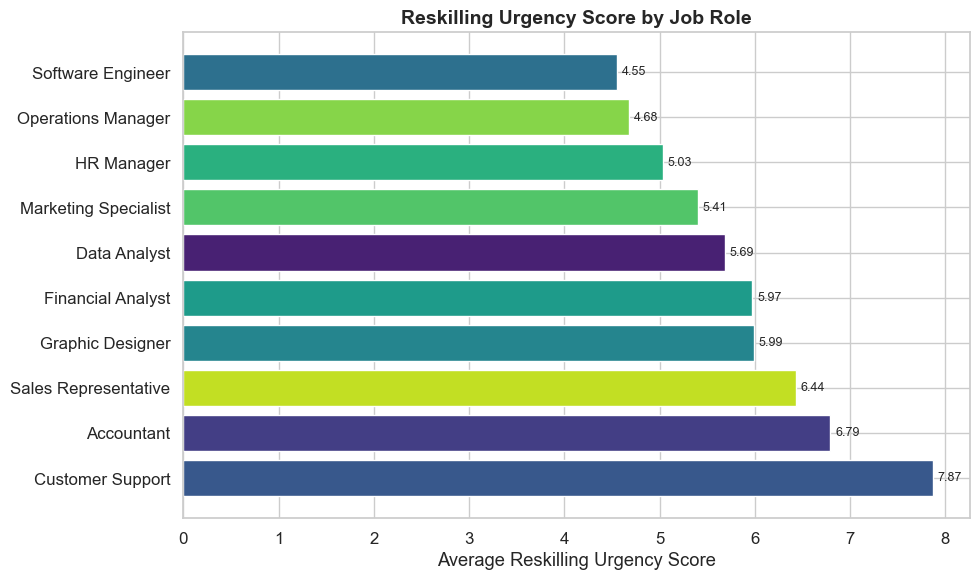

✓ Saved 2c_skill_demand_trend.png


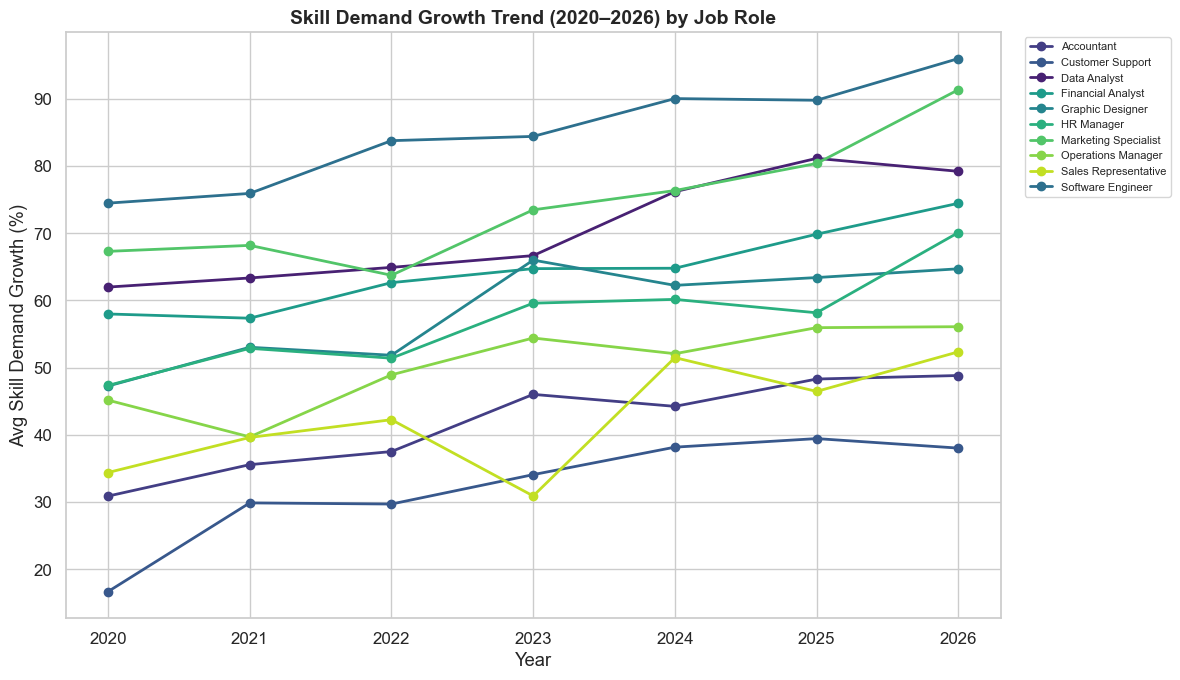


SECTION 3: SALARY & ECONOMIC IMPACT
✓ Saved 3a_salary_before_after_trend.png


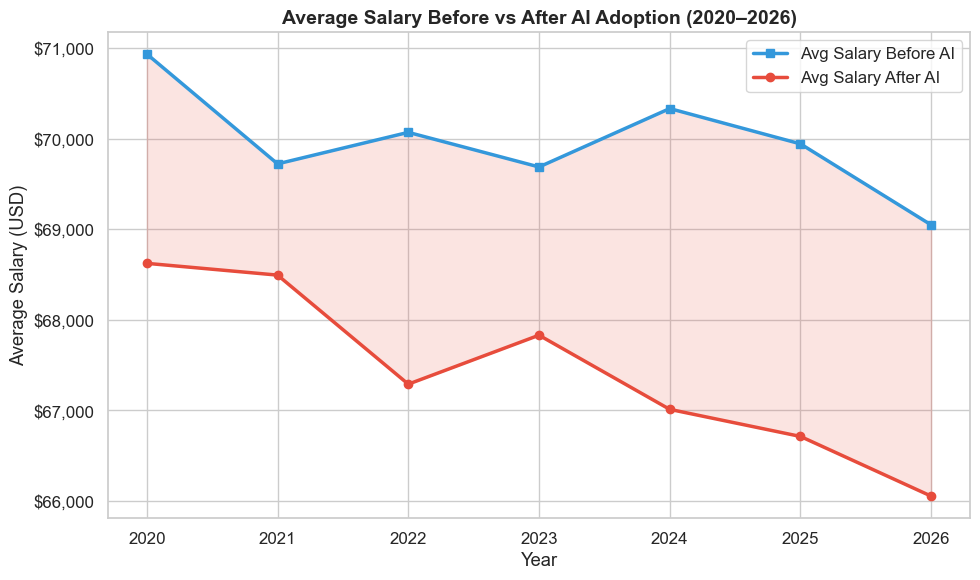

✓ Saved 3b_salary_change_by_role.png


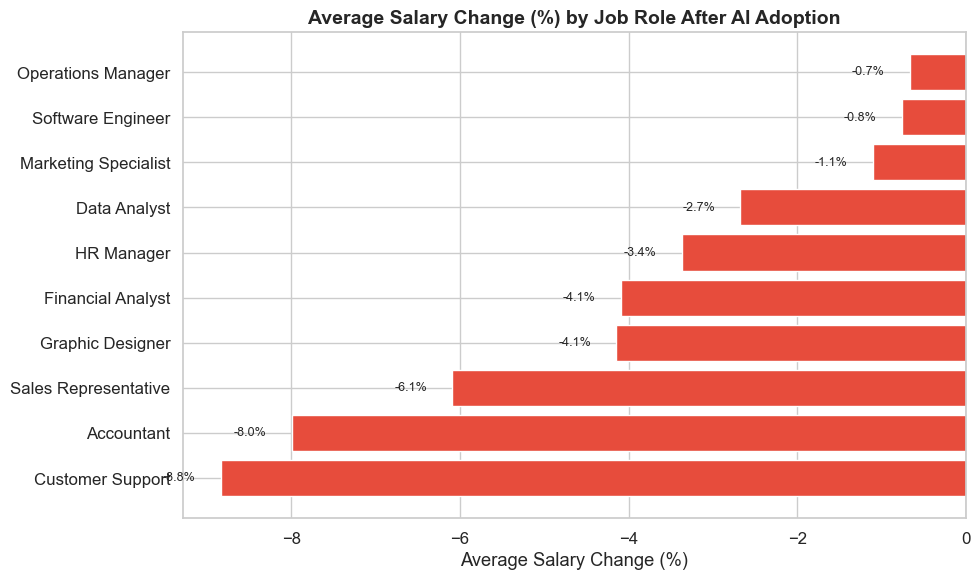

✓ Saved 3c_salary_vs_risk_regression.png


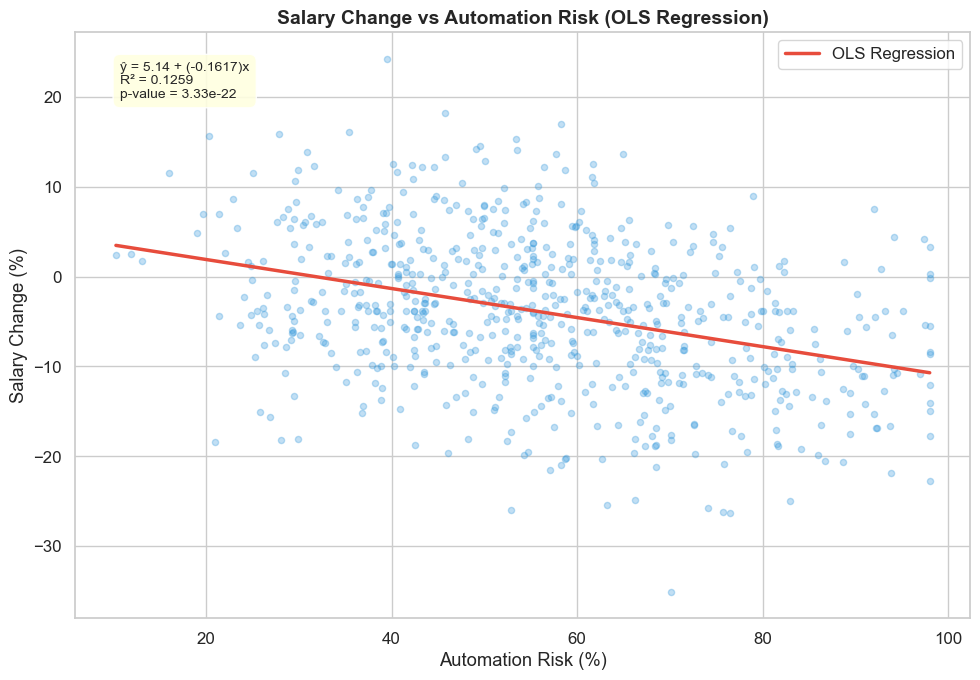


── OLS Regression Summary ──
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       5.1376      0.956      5.374      0.000       3.261       7.014
automation_risk_percent    -0.1617      0.016    -10.029      0.000      -0.193      -0.130

Interpretation: A 1 percentage-point increase in automation risk is associated with a -0.1617 percentage-point change in salary. This is statistically significant.
✓ Saved 3d_wage_volatility_by_role.png


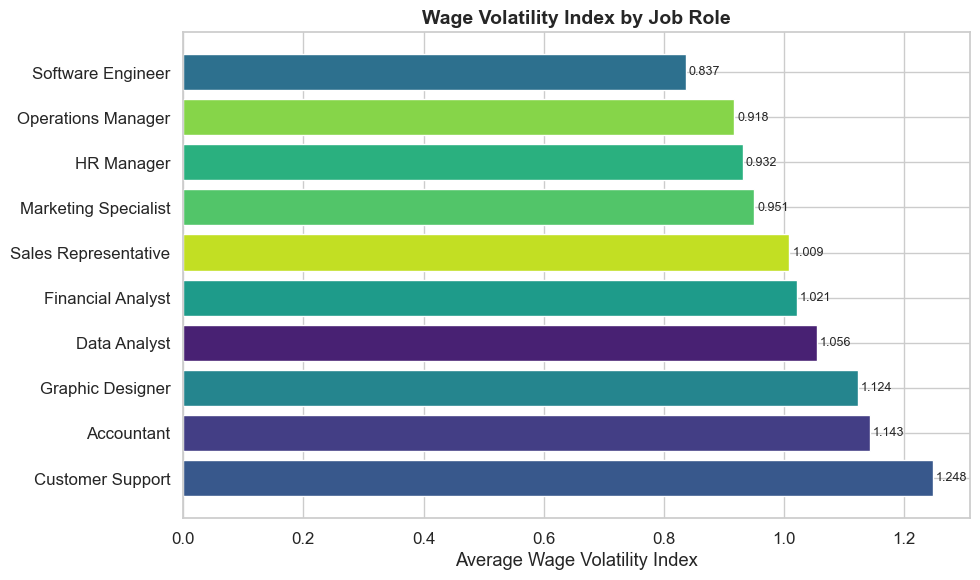


SECTION 4: NUS BBA CURRICULUM HEATMAP
✓ Saved 4_curriculum_heatmap.png


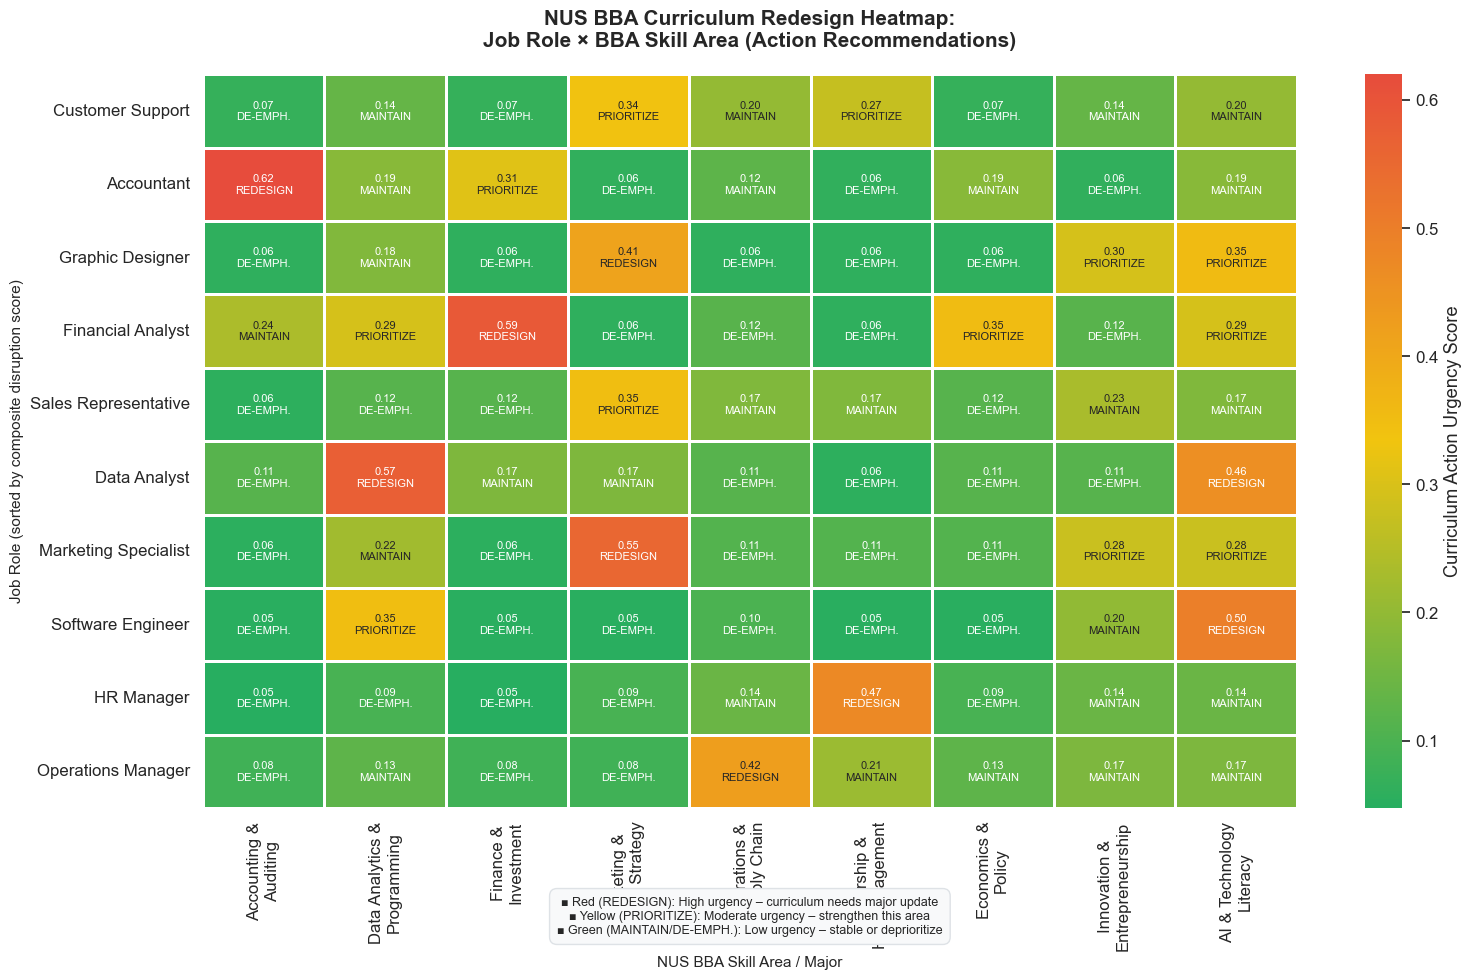


SECTION 5: STATISTICAL ANALYSIS
✓ Saved 5a_correlation_matrix.png


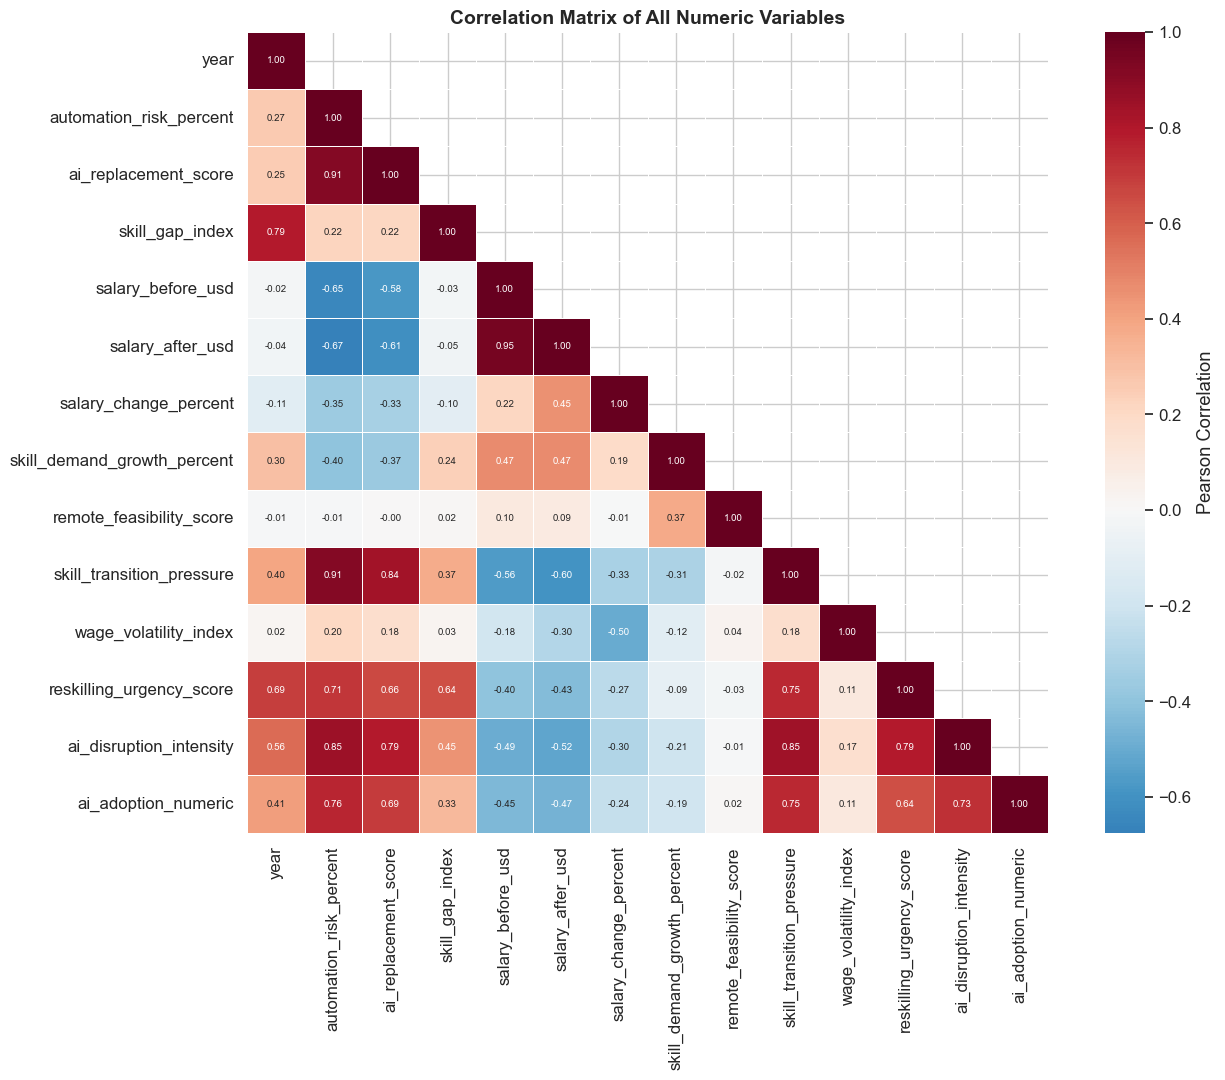


── Key Correlations with salary_change_percent ──
wage_volatility_index         -0.502884
automation_risk_percent       -0.354888
ai_replacement_score          -0.328288
skill_transition_pressure     -0.325850
ai_disruption_intensity       -0.300523
reskilling_urgency_score      -0.268958
ai_adoption_numeric           -0.242163
year                          -0.106487
skill_gap_index               -0.103394
remote_feasibility_score      -0.007139
skill_demand_growth_percent    0.192680
salary_before_usd              0.215865
salary_after_usd               0.453555

── ANOVA: salary_change_percent across automation_risk_category ──
  Shapiro-Wilk (High Risk): W=0.9782, p=4.7802e-01
  Shapiro-Wilk (Low Risk): W=0.9875, p=8.6998e-01
  Shapiro-Wilk (Medium Risk): W=0.9750, p=3.6500e-01

  One-Way ANOVA: F=54.5687, p=9.62e-23
  Kruskal-Wallis: H=92.8605, p=6.85e-21

  → Salary change differs SIGNIFICANTLY across risk categories (p < 0.05).
    Higher automation risk categories tend to exper

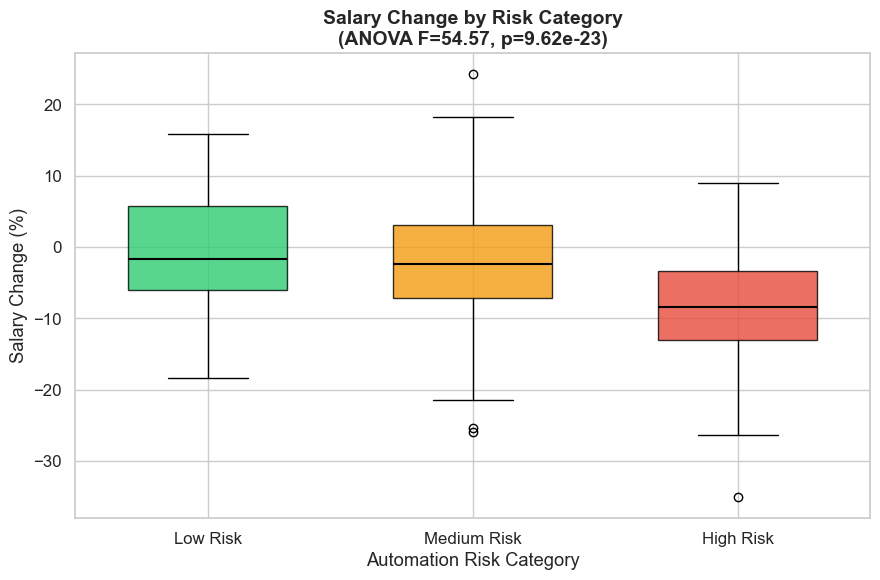


SECTION 6: FINAL SUMMARY TABLE

            Job Role  Avg Automation Risk (%)  Avg Skill Demand Growth (%)  Avg Salary Change (%) Recommended Action
    Customer Support                     86.4                         32.3                   -8.8       DE-EMPHASIZE
          Accountant                     74.2                         41.6                   -8.0       DE-EMPHASIZE
Sales Representative                     67.0                         42.5                   -6.1       DE-EMPHASIZE
    Graphic Designer                     61.9                         58.3                   -4.1           REDESIGN
   Financial Analyst                     58.8                         64.5                   -4.1           REDESIGN
        Data Analyst                     52.9                         70.5                   -2.7         PRIORITIZE
Marketing Specialist                     48.9                         74.4                   -1.1         PRIORITIZE
          HR Manager           

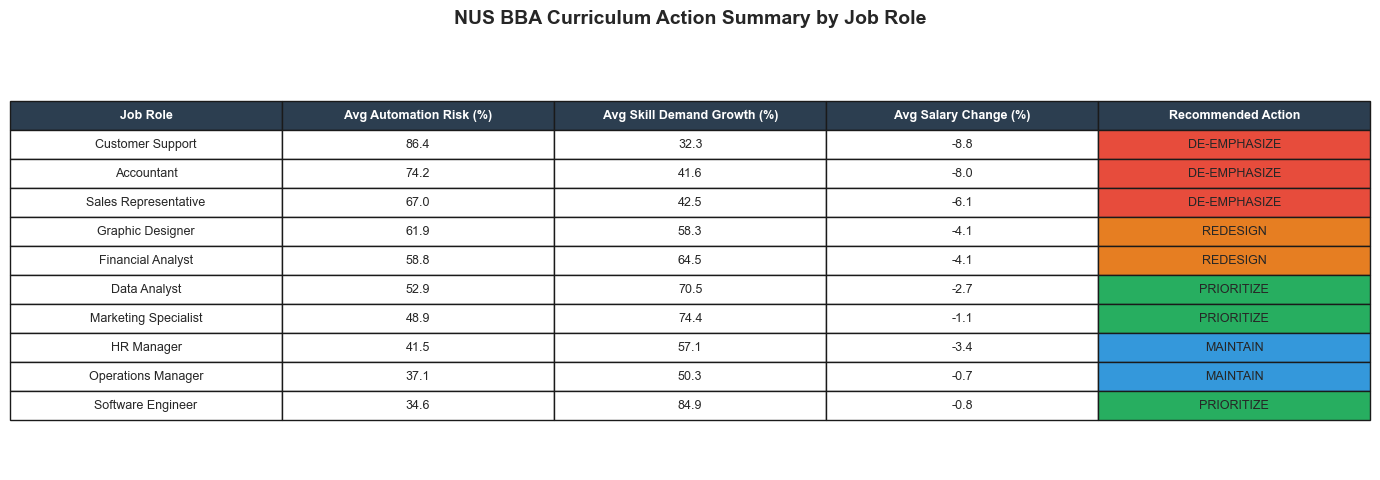


LIMITATIONS & NOTES

1. The dataset contains only 10 job roles — a simplification. However, these
   roles represent a spectrum from "repetitive/rule-based" (e.g., Customer
   Support, Accountant) to "complex problem-solving/creative" (e.g., Software
   Engineer, Operations Manager), making them suitable proxies.

2. Years 2024–2026 contain projected (not observed) data — interpret trend
   analyses with caution.

3. The NUS BBA skill mapping uses expert-assigned relevance weights. In a
   full study, these should be validated through faculty surveys or NLP
   analysis of course syllabi.

4. Salary data is in USD; NUS graduates may face different wage dynamics
   in SGD. Cross-country comparisons should account for PPP.

5. The "curriculum action" recommendations (Prioritize, Redesign, Maintain,
   De-emphasize) are directional. Implementation requires consultation with
   NUS BBA faculty, industry advisory boards, and accreditation bodies.

ANALYSIS COMPLETE – All outputs saved to ou

In [9]:
import pandas as pd

df = pd.read_csv(r"C:\Users\ohaid\Downloads\group project\NUS_BBA_Analysis\ai_job_dataset.csv")


import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

warnings.filterwarnings("ignore")


sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = sns.color_palette("viridis", 10)
ROLE_PALETTE = dict(zip([
    "Data Analyst", "Accountant", "Customer Support", "Software Engineer",
    "Graphic Designer", "Financial Analyst", "HR Manager",
    "Marketing Specialist", "Operations Manager", "Sales Representative"
], PALETTE))

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DPI = 300

def save(fig, name):
    fig.savefig(os.path.join(OUTPUT_DIR, name), dpi=DPI, bbox_inches="tight",
                facecolor="white")
    print(f"✓ Saved {name}")
    plt.show()   # ← this displays it
    
def get_role_color(role, default="gray"):
    return ROLE_PALETTE.get(role, default)

def make_boxplot(ax, data, category_col, value_col, order, colors=None):
    groups = [
        data.loc[data[category_col] == cat, value_col].dropna().values
        for cat in order
    ]

    bp = ax.boxplot(
        groups,
        tick_labels=order,
        patch_artist=True,
        widths=0.6
    )

    if colors is None:
        colors = ["lightgray"] * len(order)

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(1.5)

    return bp

# =============================================================================
# 0. DATA LOADING & CLEANING
# =============================================================================
print("=" * 70)
print("SECTION 0: DATA LOADING & CLEANING")
print("=" * 70)



print(f"\nShape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nTotal missing: {df.isnull().sum().sum()} / {df.size} "
      f"({df.isnull().sum().sum() / df.size * 100:.2f}%)")


numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        n_missing = df[col].isnull().sum()
        df[col].fillna(median_val, inplace=True)
        print(f"  → Imputed {n_missing} missing values in '{col}' with median={median_val:.2f}")


adoption_map = {"Low": 1, "Medium": 2, "High": 3}
df["ai_adoption_numeric"] = df["ai_adoption_level"].map(adoption_map)

print(f"\nPost-cleaning shape: {df.shape}")
print(f"Unique job roles ({df['job_role'].nunique()}): {sorted(df['job_role'].unique())}")
print(f"Year range: {df['year'].min()} – {df['year'].max()}")


# =============================================================================
# SECTION 1: AI DISRUPTION LANDSCAPE
# =============================================================================
print("\n" + "=" * 70)
print("SECTION 1: AI DISRUPTION LANDSCAPE")
print("=" * 70)

# ── 1a: Average AI Adoption Level by Industry ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
adoption_by_ind = (df.groupby("industry")["ai_adoption_numeric"]
                   .mean().sort_values(ascending=False))
bars = ax.barh(adoption_by_ind.index, adoption_by_ind.values, color=sns.color_palette("YlOrRd", len(adoption_by_ind)))
ax.set_xlabel("Average AI Adoption Level (1=Low, 2=Medium, 3=High)")
ax.set_title("Average AI Adoption Level by Industry", fontsize=14, fontweight="bold")
for bar, val in zip(bars, adoption_by_ind.values):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, f"{val:.2f}",
            va="center", fontsize=9)
ax.set_xlim(0, 3.5)
fig.tight_layout()
save(fig, "1a_ai_adoption_by_industry.png")

# ── 1b: Average Automation Risk % by Job Role ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
risk_by_role = (
    df.groupby("job_role")["automation_risk_percent"]
      .mean()
      .sort_values(ascending=False)
)
colors = [get_role_color(r) for r in risk_by_role.index]
bars = ax.barh(risk_by_role.index, risk_by_role.values, color=colors)
ax.set_xlabel("Average Automation Risk (%)")
ax.set_title("Average Automation Risk by Job Role", fontsize=14, fontweight="bold")
for bar, val in zip(bars, risk_by_role.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f"{val:.1f}%",
            va="center", fontsize=9)
fig.tight_layout()
save(fig, "1b_automation_risk_by_role.png")

# ── 1c: AI Disruption Intensity Heatmap (Job Role × Industry) ────────────────
fig, ax = plt.subplots(figsize=(12, 7))
pivot = df.pivot_table(values="ai_disruption_intensity",
                       index="job_role", columns="industry", aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5,
            ax=ax, cbar_kws={"label": "Avg AI Disruption Intensity"})
ax.set_title("AI Disruption Intensity: Job Role × Industry", fontsize=14, fontweight="bold")
ax.set_ylabel("")
ax.set_xlabel("")
fig.tight_layout()
save(fig, "1c_disruption_heatmap_role_industry.png")

# ── 1d: Box Plot – AI Replacement Score by Risk Category ─────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
risk_by_role = (
    df.groupby("job_role")["automation_risk_percent"]
      .mean()
      .sort_values(ascending=False)
)
colors = [get_role_color(r) for r in risk_by_role.index]
bars = ax.barh(risk_by_role.index, risk_by_role.values, color=colors)
ax.set_xlabel("Average Automation Risk (%)")
ax.set_title("Average Automation Risk by Job Role", fontsize=14, fontweight="bold")
for bar, val in zip(bars, risk_by_role.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f"{val:.1f}%",
            va="center", fontsize=9)
fig.tight_layout()
save(fig, "1b_automation_risk_by_role.png")

# =============================================================================
# SECTION 2: FUTURE SKILL DEMAND
# =============================================================================
print("\n" + "=" * 70)
print("SECTION 2: FUTURE SKILL DEMAND")
print("=" * 70)

role_agg = df.groupby("job_role").agg(
    avg_skill_demand=("skill_demand_growth_percent", "mean"),
    avg_automation_risk=("automation_risk_percent", "mean"),
    avg_reskilling=("reskilling_urgency_score", "mean"),
    avg_disruption=("ai_disruption_intensity", "mean"),
    avg_salary_change=("salary_change_percent", "mean"),
).reset_index()

# ── 2a: KEY SCATTER – Quadrant Chart ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))

med_x = role_agg["avg_skill_demand"].median()
med_y = role_agg["avg_automation_risk"].median()

for _, row in role_agg.iterrows():
    ax.scatter(
        row["avg_skill_demand"],
        row["avg_automation_risk"],
        color=get_role_color(row["job_role"]),
        s=200,
        zorder=5,
        edgecolors="black",
        linewidth=0.8
    )
    ax.annotate(
        row["job_role"],
        (row["avg_skill_demand"], row["avg_automation_risk"]),
        textcoords="offset points",
        xytext=(8, 6),
        fontsize=9,
        fontweight="bold"
    )

# Quadrant lines
ax.axvline(med_x, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)
ax.axhline(med_y, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)

# Quadrant labels
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
pad_x = (x_max - x_min) * 0.02
pad_y = (y_max - y_min) * 0.02

ax.text(x_min + pad_x, y_max - pad_y,
        "High Risk / Low Growth\n→ DE-EMPHASIZE",
        fontsize=10, fontweight="bold", color="#e74c3c", va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#fdecea", alpha=0.85))
ax.text(x_max - pad_x, y_max - pad_y,
        "High Risk / High Growth\n→ REDESIGN",
        fontsize=10, fontweight="bold", color="#e67e22", va="top", ha="right",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#fef5e7", alpha=0.85))
ax.text(x_max - pad_x, y_min + pad_y,
        "Low Risk / High Growth\n→ PRIORITIZE",
        fontsize=10, fontweight="bold", color="#27ae60", va="bottom", ha="right",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#eafaf1", alpha=0.85))
ax.text(x_min + pad_x, y_min + pad_y,
        "Low Risk / Low Growth\n→ MAINTAIN",
        fontsize=10, fontweight="bold", color="#2980b9", va="bottom", ha="left",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#ebf5fb", alpha=0.85))

ax.set_xlabel("Average Skill Demand Growth (%)", fontsize=12)
ax.set_ylabel("Average Automation Risk (%)", fontsize=12)
ax.set_title("NUS BBA Curriculum Action Matrix:\nSkill Demand Growth vs Automation Risk by Job Role",
             fontsize=14, fontweight="bold")
fig.tight_layout()
save(fig, "2a_quadrant_scatter_KEY.png")

# ── 2b: Reskilling Urgency by Job Role ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
reskill = role_agg.sort_values("avg_reskilling", ascending=False)
colors = [get_role_color(r) for r in reskill["job_role"]]
bars = ax.barh(reskill["job_role"], reskill["avg_reskilling"], color=colors)
ax.set_xlabel("Average Reskilling Urgency Score")
ax.set_title("Reskilling Urgency Score by Job Role", fontsize=14, fontweight="bold")
for bar, val in zip(bars, reskill["avg_reskilling"]):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, f"{val:.2f}",
            va="center", fontsize=9)
fig.tight_layout()
save(fig, "2b_reskilling_urgency_by_role.png")

# ── 2c: Skill Demand Growth Trend Over Time ──────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
trend = df.groupby(["year", "job_role"])["skill_demand_growth_percent"].mean().reset_index()

for role in sorted(df["job_role"].unique()):
    subset = trend[trend["job_role"] == role]
    ax.plot(
        subset["year"],
        subset["skill_demand_growth_percent"],
        marker="o",
        label=role,
        color=get_role_color(role),
        linewidth=2
    )
    
ax.set_xlabel("Year")
ax.set_ylabel("Avg Skill Demand Growth (%)")
ax.set_title("Skill Demand Growth Trend (2020–2026) by Job Role",
             fontsize=14, fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
fig.tight_layout()
save(fig, "2c_skill_demand_trend.png")


# =============================================================================
# SECTION 3: SALARY & ECONOMIC IMPACT
# =============================================================================
print("\n" + "=" * 70)
print("SECTION 3: SALARY & ECONOMIC IMPACT")
print("=" * 70)

# ── 3a: Dual-Line – Avg Salary Before vs After by Year ──────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
sal_year = df.groupby("year").agg(
    sal_before=("salary_before_usd", "mean"),
    sal_after=("salary_after_usd", "mean"),
).reset_index()
ax.plot(sal_year["year"], sal_year["sal_before"], marker="s", linewidth=2.5,
        label="Avg Salary Before AI", color="#3498db")
ax.plot(sal_year["year"], sal_year["sal_after"], marker="o", linewidth=2.5,
        label="Avg Salary After AI", color="#e74c3c")
ax.fill_between(sal_year["year"], sal_year["sal_before"], sal_year["sal_after"],
                alpha=0.15, color="#e74c3c")
ax.set_xlabel("Year")
ax.set_ylabel("Average Salary (USD)")
ax.set_title("Average Salary Before vs After AI Adoption (2020–2026)",
             fontsize=14, fontweight="bold")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
fig.tight_layout()
save(fig, "3a_salary_before_after_trend.png")

# ── 3b: Salary Change % by Job Role ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
sal_role = role_agg.sort_values("avg_salary_change")
bar_colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in sal_role["avg_salary_change"]]
bars = ax.barh(sal_role["job_role"], sal_role["avg_salary_change"], color=bar_colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Average Salary Change (%)")
ax.set_title("Average Salary Change (%) by Job Role After AI Adoption",
             fontsize=14, fontweight="bold")
for bar, val in zip(bars, sal_role["avg_salary_change"]):
    offset = 0.3 if val >= 0 else -0.3
    ha = "left" if val >= 0 else "right"
    ax.text(val + offset, bar.get_y() + bar.get_height()/2, f"{val:+.1f}%",
            va="center", ha=ha, fontsize=9)
fig.tight_layout()
save(fig, "3b_salary_change_by_role.png")

# ── 3c: Scatter + OLS – Salary Change vs Automation Risk ─────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
x = df["automation_risk_percent"].dropna()
y = df.loc[x.index, "salary_change_percent"].dropna()
x = x.loc[y.index]

ax.scatter(x, y, alpha=0.3, s=20, color="#3498db")

# OLS Regression
X_ols = sm.add_constant(x)
model = sm.OLS(y, X_ols).fit()
x_line = np.linspace(x.min(), x.max(), 100)
y_line = model.params[0] + model.params[1] * x_line
ax.plot(x_line, y_line, color="#e74c3c", linewidth=2.5, label="OLS Regression")

eq_text = (f"ŷ = {model.params[0]:.2f} + ({model.params[1]:.4f})x\n"
           f"R² = {model.rsquared:.4f}\n"
           f"p-value = {model.pvalues[1]:.2e}")
ax.text(0.05, 0.95, eq_text, transform=ax.transAxes, fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.9))

ax.set_xlabel("Automation Risk (%)")
ax.set_ylabel("Salary Change (%)")
ax.set_title("Salary Change vs Automation Risk (OLS Regression)",
             fontsize=14, fontweight="bold")
ax.legend()
fig.tight_layout()
save(fig, "3c_salary_vs_risk_regression.png")

print("\n── OLS Regression Summary ──")
print(model.summary().tables[1])
print(f"\nInterpretation: A 1 percentage-point increase in automation risk is associated "
      f"with a {model.params[1]:.4f} percentage-point change in salary. "
      f"{'This is statistically significant.' if model.pvalues[1] < 0.05 else 'This is NOT statistically significant.'}")

# ── 3d: Wage Volatility Index by Job Role ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
wv = df.groupby("job_role")["wage_volatility_index"].mean().sort_values(ascending=False)
colors = [get_role_color(r) for r in wv.index]
bars = ax.barh(wv.index, wv.values, color=colors)
ax.set_xlabel("Average Wage Volatility Index")
ax.set_title("Wage Volatility Index by Job Role", fontsize=14, fontweight="bold")
for bar, val in zip(bars, wv.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f"{val:.3f}",
            va="center", fontsize=9)
fig.tight_layout()
save(fig, "3d_wage_volatility_by_role.png")


# =============================================================================
# SECTION 4: NUS BBA CURRICULUM HEATMAP
# =============================================================================
print("\n" + "=" * 70)
print("SECTION 4: NUS BBA CURRICULUM HEATMAP")
print("=" * 70)

bba_skills = [
    "Accounting &\nAuditing",
    "Data Analytics &\nProgramming",
    "Finance &\nInvestment",
    "Marketing &\nDigital Strategy",
    "Operations &\nSupply Chain",
    "Leadership &\nHR Management",
    "Economics &\nPolicy",
    "Innovation &\nEntrepreneurship",
    "AI & Technology\nLiteracy",
]

# Mapping: each job role → relevance weights to BBA skill areas (0–1)
# Higher weight = stronger association
role_skill_map = {
    "Accountant":           [1.0, 0.3, 0.5, 0.1, 0.2, 0.1, 0.3, 0.1, 0.3],
    "Data Analyst":         [0.2, 1.0, 0.3, 0.3, 0.2, 0.1, 0.2, 0.2, 0.8],
    "Customer Support":     [0.1, 0.2, 0.1, 0.5, 0.3, 0.4, 0.1, 0.2, 0.3],
    "Software Engineer":    [0.1, 0.7, 0.1, 0.1, 0.2, 0.1, 0.1, 0.4, 1.0],
    "Graphic Designer":     [0.1, 0.3, 0.1, 0.7, 0.1, 0.1, 0.1, 0.5, 0.6],
    "Financial Analyst":    [0.4, 0.5, 1.0, 0.1, 0.2, 0.1, 0.6, 0.2, 0.5],
    "HR Manager":           [0.1, 0.2, 0.1, 0.2, 0.3, 1.0, 0.2, 0.3, 0.3],
    "Marketing Specialist": [0.1, 0.4, 0.1, 1.0, 0.2, 0.2, 0.2, 0.5, 0.5],
    "Operations Manager":   [0.2, 0.3, 0.2, 0.2, 1.0, 0.5, 0.3, 0.4, 0.4],
    "Sales Representative": [0.1, 0.2, 0.2, 0.6, 0.3, 0.3, 0.2, 0.4, 0.3],
}

# Compute composite urgency score for each role
# Composite = weighted combo of: automation_risk, skill_demand_growth,
#             reskilling_urgency, ai_disruption_intensity
def composite_score(row):
    return (0.30 * row["avg_automation_risk"] / 100 +
            0.25 * row["avg_skill_demand"] / 100 +
            0.25 * row["avg_reskilling"] / 10 +
            0.20 * row["avg_disruption"] / 10)

role_agg["composite"] = role_agg.apply(composite_score, axis=1)

role_agg_heatmap = role_agg[role_agg["job_role"].isin(role_skill_map.keys())].copy()

heatmap_data = np.zeros((len(role_agg_heatmap), len(bba_skills)))
role_order = role_agg_heatmap.sort_values("composite", ascending=False)["job_role"].tolist()

for i, role in enumerate(role_order):
    comp = role_agg_heatmap.loc[role_agg_heatmap["job_role"] == role, "composite"].values[0]
    weights = role_skill_map[role]
    for j, w in enumerate(weights):
        heatmap_data[i, j] = comp * w

heatmap_df = pd.DataFrame(heatmap_data, index=role_order, columns=bba_skills)

# Determine action labels
def action_label(val, max_val):
    ratio = val / max_val if max_val > 0 else 0
    if ratio >= 0.6:
        return "REDESIGN"
    elif ratio >= 0.4:
        return "PRIORITIZE"
    elif ratio >= 0.2:
        return "MAINTAIN"
    else:
        return "DE-EMPH."

max_val = heatmap_data.max()
annot_labels = np.empty(heatmap_data.shape, dtype=object)
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data[i, j]
        label = action_label(val, max_val)
        annot_labels[i, j] = f"{val:.2f}\n{label}"

# Plot
fig, ax = plt.subplots(figsize=(16, 10))
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("action",
    ["#27ae60", "#f1c40f", "#e74c3c"], N=256)

sns.heatmap(heatmap_df, annot=annot_labels, fmt="", cmap=cmap,
            linewidths=1, linecolor="white", ax=ax,
            cbar_kws={"label": "Curriculum Action Urgency Score"},
            annot_kws={"fontsize": 8})
ax.set_title("NUS BBA Curriculum Redesign Heatmap:\nJob Role × BBA Skill Area (Action Recommendations)",
             fontsize=15, fontweight="bold", pad=20)
ax.set_ylabel("Job Role (sorted by composite disruption score)", fontsize=11)
ax.set_xlabel("NUS BBA Skill Area / Major", fontsize=11)

# Legend box
legend_text = ("■ Red (REDESIGN): High urgency – curriculum needs major update\n"
               "■ Yellow (PRIORITIZE): Moderate urgency – strengthen this area\n"
               "■ Green (MAINTAIN/DE-EMPH.): Low urgency – stable or deprioritize")
ax.text(0.5, -0.12, legend_text, transform=ax.transAxes, fontsize=9,
        ha="center", va="top",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#f8f9fa", edgecolor="#dee2e6"))

fig.tight_layout()
save(fig, "4_curriculum_heatmap.png")


# =============================================================================
# SECTION 5: STATISTICAL ANALYSIS
# =============================================================================
print("\n" + "=" * 70)
print("SECTION 5: STATISTICAL ANALYSIS")
print("=" * 70)

# ── 5a: Correlation Matrix ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))
corr_cols = [c for c in numeric_cols if c != "job_id"]
corr_cols.append("ai_adoption_numeric")
corr = df[corr_cols].corr()
mask_upper = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask_upper, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax, square=True,
            cbar_kws={"label": "Pearson Correlation"},
            annot_kws={"fontsize": 7})
ax.set_title("Correlation Matrix of All Numeric Variables",
             fontsize=14, fontweight="bold")
fig.tight_layout()
save(fig, "5a_correlation_matrix.png")

print("\n── Key Correlations with salary_change_percent ──")
sc_corr = corr["salary_change_percent"].drop("salary_change_percent").sort_values()
print(sc_corr.to_string())

# ── 5b: ANOVA / Kruskal-Wallis Test ─────────────────────────────────────────
print("\n── ANOVA: salary_change_percent across automation_risk_category ──")
groups = [g["salary_change_percent"].values
          for _, g in df.groupby("automation_risk_category")]
group_names = sorted(df["automation_risk_category"].unique())

# Check normality for each group (Shapiro-Wilk on sample)
for name, g in zip(group_names, groups):
    sample = g[:50] if len(g) > 50 else g
    stat, p = stats.shapiro(sample)
    print(f"  Shapiro-Wilk ({name}): W={stat:.4f}, p={p:.4e}")

# One-way ANOVA
f_stat, p_anova = stats.f_oneway(*groups)
print(f"\n  One-Way ANOVA: F={f_stat:.4f}, p={p_anova:.2e}")

# Kruskal-Wallis (non-parametric alternative)
h_stat, p_kw = stats.kruskal(*groups)
print(f"  Kruskal-Wallis: H={h_stat:.4f}, p={p_kw:.2e}")

if p_anova < 0.05:
    print("\n  → Salary change differs SIGNIFICANTLY across risk categories (p < 0.05).")
    print("    Higher automation risk categories tend to experience larger salary declines.")
else:
    print("\n  → No significant difference in salary change across risk categories (p ≥ 0.05).")

# ── 5c: Box plot for ANOVA visualization ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
order = ["Low Risk", "Medium Risk", "High Risk"]
box_colors = ["#2ecc71", "#f39c12", "#e74c3c"]

make_boxplot(
    ax=ax,
    data=df,
    category_col="automation_risk_category",
    value_col="salary_change_percent",
    order=order,
    colors=box_colors
)

ax.set_xlabel("Automation Risk Category")
ax.set_ylabel("Salary Change (%)")
ax.set_title(f"Salary Change by Risk Category\n(ANOVA F={f_stat:.2f}, p={p_anova:.2e})",
             fontsize=14, fontweight="bold")
fig.tight_layout()
save(fig, "5c_anova_salary_by_risk.png")

# =============================================================================
# SECTION 6: FINAL SUMMARY TABLE
# =============================================================================
print("\n" + "=" * 70)
print("SECTION 6: FINAL SUMMARY TABLE")
print("=" * 70)

# Assign curriculum action based on quadrant position
def assign_action(row):
    high_risk = row["avg_automation_risk"] >= med_y
    high_demand = row["avg_skill_demand"] >= med_x
    if high_risk and high_demand:
        return "REDESIGN"
    elif high_risk and not high_demand:
        return "DE-EMPHASIZE"
    elif not high_risk and high_demand:
        return "PRIORITIZE"
    else:
        return "MAINTAIN"

role_agg["curriculum_action"] = role_agg.apply(assign_action, axis=1)

summary = role_agg[["job_role", "avg_automation_risk", "avg_skill_demand",
                     "avg_salary_change", "curriculum_action"]].copy()
summary.columns = ["Job Role", "Avg Automation Risk (%)", "Avg Skill Demand Growth (%)",
                    "Avg Salary Change (%)", "Recommended Action"]
summary = summary.sort_values("Avg Automation Risk (%)", ascending=False)

print("\n" + summary.to_string(index=False, float_format=lambda x: f"{x:.1f}"))

# Save summary as CSV too
summary.to_csv(os.path.join(OUTPUT_DIR, "summary_table.csv"), index=False)
print(f"\n  ✓ Saved summary_table.csv")

# ── Pretty summary table as figure ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis("off")

action_colors = {
    "PRIORITIZE": "#27ae60", "REDESIGN": "#e67e22",
    "MAINTAIN": "#3498db", "DE-EMPHASIZE": "#e74c3c"
}

cell_colors = []
display_vals = []
for _, row in summary.iterrows():
    c = action_colors.get(row["Recommended Action"], "white")
    cell_colors.append(["white"] * 4 + [c])
    display_vals.append([
        row["Job Role"],
        f"{row['Avg Automation Risk (%)']:.1f}",
        f"{row['Avg Skill Demand Growth (%)']:.1f}",
        f"{row['Avg Salary Change (%)']:.1f}",
        row["Recommended Action"],
    ])

table = ax.table(cellText=display_vals, colLabels=summary.columns,
                 cellLoc="center", loc="center",
                 cellColours=cell_colors)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

# Style header
for j in range(len(summary.columns)):
    table[0, j].set_facecolor("#2c3e50")
    table[0, j].set_text_props(color="white", fontweight="bold")

ax.set_title("NUS BBA Curriculum Action Summary by Job Role",
             fontsize=14, fontweight="bold", pad=20)
fig.tight_layout()
save(fig, "6_summary_table.png")


# =============================================================================
# LIMITATIONS & NOTES
# =============================================================================
print("\n" + "=" * 70)
print("LIMITATIONS & NOTES")
print("=" * 70)
print("""
1. The dataset contains only 10 job roles — a simplification. However, these
   roles represent a spectrum from "repetitive/rule-based" (e.g., Customer
   Support, Accountant) to "complex problem-solving/creative" (e.g., Software
   Engineer, Operations Manager), making them suitable proxies.

2. Years 2024–2026 contain projected (not observed) data — interpret trend
   analyses with caution.

3. The NUS BBA skill mapping uses expert-assigned relevance weights. In a
   full study, these should be validated through faculty surveys or NLP
   analysis of course syllabi.

4. Salary data is in USD; NUS graduates may face different wage dynamics
   in SGD. Cross-country comparisons should account for PPP.

5. The "curriculum action" recommendations (Prioritize, Redesign, Maintain,
   De-emphasize) are directional. Implementation requires consultation with
   NUS BBA faculty, industry advisory boards, and accreditation bodies.
""")

print("=" * 70)
print("ANALYSIS COMPLETE – All outputs saved to outputs/ folder")
print("=" * 70)
